   PMT_voltage  mean_photon_count
0         0.00                0.5
1         0.50                0.0
2         0.55                0.8
3         0.60                2.7
4         0.65                7.8
5         0.70               12.5
6         0.75               15.4
7         0.80               17.6
8         0.85               22.0

Saved data to:
/Users/zipeiwu/Desktop/BU/lab/projects/imaging/single_photon_counting/scope/notrigger/20260604_PMTcontrol_volatge/PMT_voltage_vs_photon_count.csv


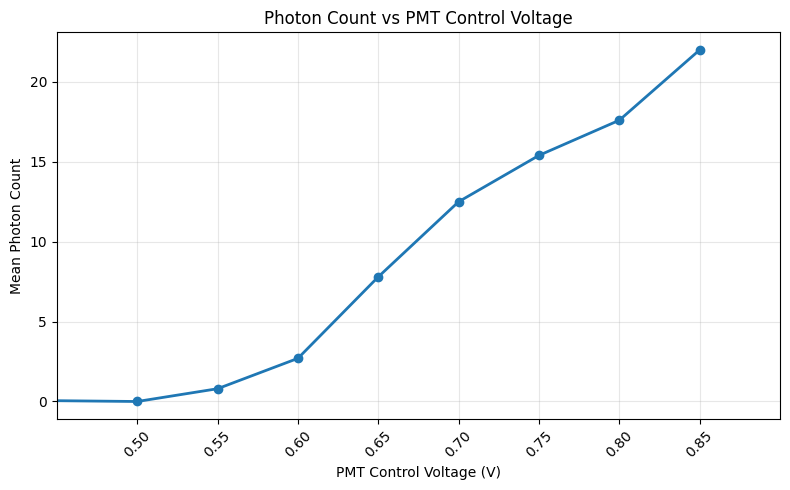


Saved figure to:
/Users/zipeiwu/Desktop/BU/lab/projects/imaging/single_photon_counting/scope/notrigger/20260604_PMTcontrol_volatge/PMT_voltage_vs_photon_count.png


In [7]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Root directory
# ============================================================

root_dir = Path(
    "/Users/zipeiwu/Desktop/BU/lab/projects/imaging/single_photon_counting/scope/notrigger/20260604_PMTcontrol_volatge"
)

# ============================================================
# Read all PMT folders and collect mean photon counts
# ============================================================

results = []

for folder in root_dir.iterdir():

    if not folder.is_dir():
        continue

    if not folder.name.startswith("PMT="):
        continue

    try:
        voltage = float(folder.name.split("=")[1])
    except ValueError:
        print(f"Skipping folder: {folder.name}")
        continue

    summary_file = folder / "final_summary.csv"

    if not summary_file.exists():
        print(f"Missing file: {summary_file}")
        continue

    try:
        df = pd.read_csv(summary_file)

        mean_row = df[
            df["Metric"].str.strip() == "Mean photon count"
        ]

        if len(mean_row) == 0:
            print(
                f"'Mean photon count' not found in {summary_file}"
            )
            continue

        mean_photon_count = float(
            mean_row.iloc[0]["Value"]
        )

        results.append(
            {
                "PMT_voltage": voltage,
                "mean_photon_count": mean_photon_count,
            }
        )

    except Exception as e:
        print(f"Error reading {summary_file}: {e}")

# ============================================================
# Convert to DataFrame
# ============================================================

results_df = pd.DataFrame(results)

if len(results_df) == 0:
    raise RuntimeError("No valid PMT data found.")

results_df = (
    results_df
    .sort_values("PMT_voltage")
    .reset_index(drop=True)
)

print(results_df)

# ============================================================
# Save combined data
# ============================================================

output_csv = root_dir / "PMT_voltage_vs_photon_count.csv"

results_df.to_csv(
    output_csv,
    index=False
)

print(f"\nSaved data to:\n{output_csv}")

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    results_df["PMT_voltage"],
    results_df["mean_photon_count"],
    marker="o",
    linewidth=2,
)

plt.xlabel("PMT Control Voltage (V)")
plt.ylabel("Mean Photon Count")
plt.title("Photon Count vs PMT Control Voltage")

# Show ALL voltage values on x-axis
plt.xticks(
    results_df["PMT_voltage"],
    [f"{v:.2f}" for v in results_df["PMT_voltage"]],
    rotation=45,
)
plt.xlim(0.45,0.9)
plt.grid(True, alpha=0.3)

plt.tight_layout()

# ============================================================
# Save figure
# ============================================================

output_png = root_dir / "PMT_voltage_vs_photon_count.png"

plt.savefig(
    output_png,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"\nSaved figure to:\n{output_png}")